# AI 기반 시간 예측 데이터를 활용한 스마트 환기 운영 최적화 제안
## 서울교통공사 에너지 효율 개선 입찰 제안서


---

## SCQA

### S (Situation)
서울교통공사는 지하철 내 쾌적한 환경을 유지하기 위해 냉방·환기 시스템을 운영하고 있다. 현재는 열차 무게, 공기질 센서, CCTV 데이터를 활용하여 환기 설비를 제어하고 있으며, 이를 통해 실내 공기질을 관리하고 있다.

### C (Complication)
그러나 현재 시스템은 승객 증가나 공기질 변화가 발생한 이후에 대응하는 방식이다. 또한 이용객이 적은 시간대에도 불필요한 환기 운영이 발생할 수 있어 에너지 효율 측면에서 한계가 존재한다.

### Q (Question)
현재 활용 중인 데이터만으로 환기 시스템을 운영하는 것이 최선일까? 이용객이 집중되는 시간과 장소를 미리 예측하여 환기 설비를 더욱 효율적으로 운영할 수는 없을까?

### A (Answer)
본 프로젝트는 시간대별 승하차 데이터를 활용하여 이용객 집중 패턴을 분석하고자 한다. 이를 통해 혼잡도를 사전에 예측하고, 환기 설비를 선제적으로 운영하는 데이터 기반 스마트 환기 시스템을 제안한다.


## 민토 피라미드

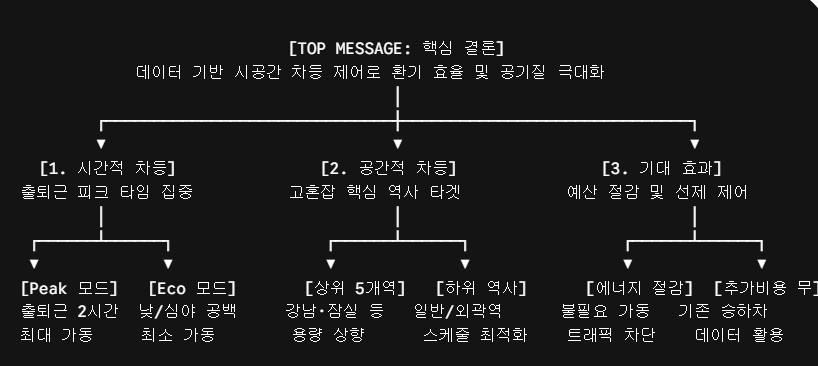

## 프로젝트 개요
---
서울교통공사는 지하철 역사와 열차 내부의 공기질을 관리하기 위해 냉방·환기 시스템을 운영하고 있다. 현재는 열차 무게, 공기질 센서, CCTV 영상 데이터 등을 활용해 환기 설비를 제어하고 있으나, 승객 증가나 공기질 변화가 발생한 이후 대응하는 사후 대응형 운영이라는 한계가 있다.

본 프로젝트는 서울시 지하철 호선별·역별·시간대별 승하차 인원 데이터를 분석하여 이용객 집중 패턴을 파악하고, 특정 호선·역·시간대의 혼잡이 통계적으로 유의미한지 검증한다. 이를 바탕으로 혼잡도 예측 가능성을 확인하고, 기존 환기 운영 시스템에 시간대별 이용객 데이터를 추가 활용하는 방안을 제안한다. 이를 통해 환기 설비를 사후 대응형에서 선제 대응형으로 전환하여 공기질 개선과 에너지 효율 향상을 동시에 달성할 수 있는 스마트 환기 운영 전략을 제시하고자 한다.

**데이터 출처:** https://www.data.go.kr/index.do

---
# 가설 설정
- 귀무가설 (H₀):
시간대 간 평균 유동인구의 차이가 없다.
(즉, 출퇴근 시간대와 비출퇴근 시간대의 평균 유동인구는 동일하다.)
- 대립가설 (H₁):
출퇴근 시간대의 평균 유동인구는 비출퇴근 시간대와 다르다.
(즉, 두 시간대의 평균 유동인구에는 유의미한 차이가 있다.)



# 검정 방법

*   독립표본 t-검정 (Independent Samples t-test)
    *   비교 대상: 출퇴근 시간대 그룹 vs 비출퇴근 시간대 그룹



# 판단 기준
- 유의수준(α) = 0.05
- p-value < 0.05이면 귀무가설을 기각하고, 출퇴근 시간대와 비출퇴근 시간대의 평균 유동인구는 통계적으로 유의미한 차이가 있다고 판단한다.
- p-value ≥ 0.05이면 귀무가설을 기각하지 못하며, 두 시간대의 평균 유동인구 차이가 통계적으로 유의미하다고 볼 근거가 부족하다고 판단한다.

---

## 1. 데이터 불러오기

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
## 2026년 01월 ~ 05월 까지 호선, 시간subway_{month별 승하차 인원 문서 merge

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # 에러 해결: plt 불러오기
import matplotlib as mpl
import matplotlib.font_manager as fm

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"

raw_frames = []
# 1. month를 문자열 리스트로 처리
for month in ["01", "02", "03", "04", "05"]:
    file_path = f"{DATA_PATH}}.csv"
    # 파일 읽기
    df = pd.read_csv(file_path, encoding='cp949')
    raw_frames.append(df)

# 리스트에 담긴 데이터프레임들을 하나로 합침
raw = pd.concat(raw_frames, ignore_index=True)

# 1~9호선 리스트 정의
TARGET_LINES = ['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선', '9호선']

# 데이터 불러온 후 즉시 필터링 적용
raw = raw[raw['호선명'].isin(TARGET_LINES)].copy()

raw.head()


,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202601,1호선,동대문,737,20,10317,1768,8227,5709,12914,...,9845,856,2927,10,271,0,0,0,0,20260203
1,202601,1호선,동묘앞,189,4,2792,903,3750,5359,8408,...,4708,158,2158,3,254,0,0,0,0,20260203
2,202601,1호선,서울역,695,62,10351,9807,31743,55994,96412,...,29013,3388,6760,37,218,0,1,0,0,20260203
3,202601,1호선,시청,94,1,1748,5378,3421,28279,7063,...,3289,560,751,2,22,0,0,0,0,20260203
4,202601,1호선,신설동,483,6,7656,2163,9461,8062,21498,...,8681,488,2485,10,32,0,0,0,0,20260203


# 시간대별 호선별 승하차 격차 추이

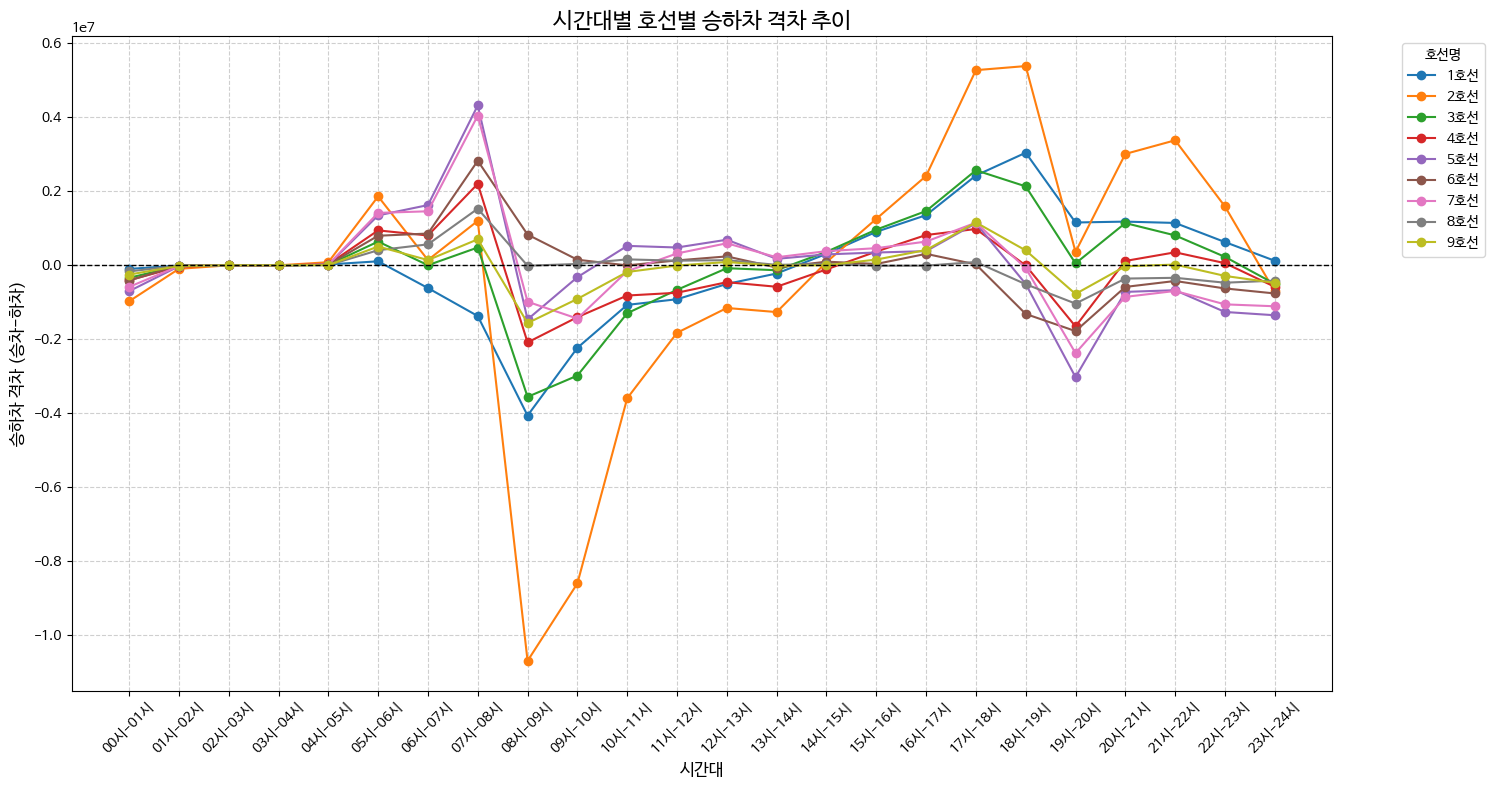

In [ ]:
# 1. 시각화를 위해 피벗 데이터 사용
pivot_line_time = df_final.pivot_table(
    index='시간대',
    columns='호선명',
    values='인원수',
    aggfunc=lambda x: x[df_final['구분']=='승차'].sum() - x[df_final['구분']=='하차'].sum()
)

# 2. 선 그래프 시각화
plt.figure(figsize=(15, 8))
# 모든 호선을 선으로 그립니다.
for line in pivot_line_time.columns:
    plt.plot(pivot_line_time.index, pivot_line_time[line], marker='o', label=line)

# 그래프 꾸미기
plt.title('시간대별 호선별 승하차 격차 추이', fontsize=16)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('승하차 격차 (승차-하차)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--', linewidth=1) # 기준선
plt.legend(title='호선명', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# 강남, 잠실, 홍대입구역 시간대별 일평균 승하차 격차

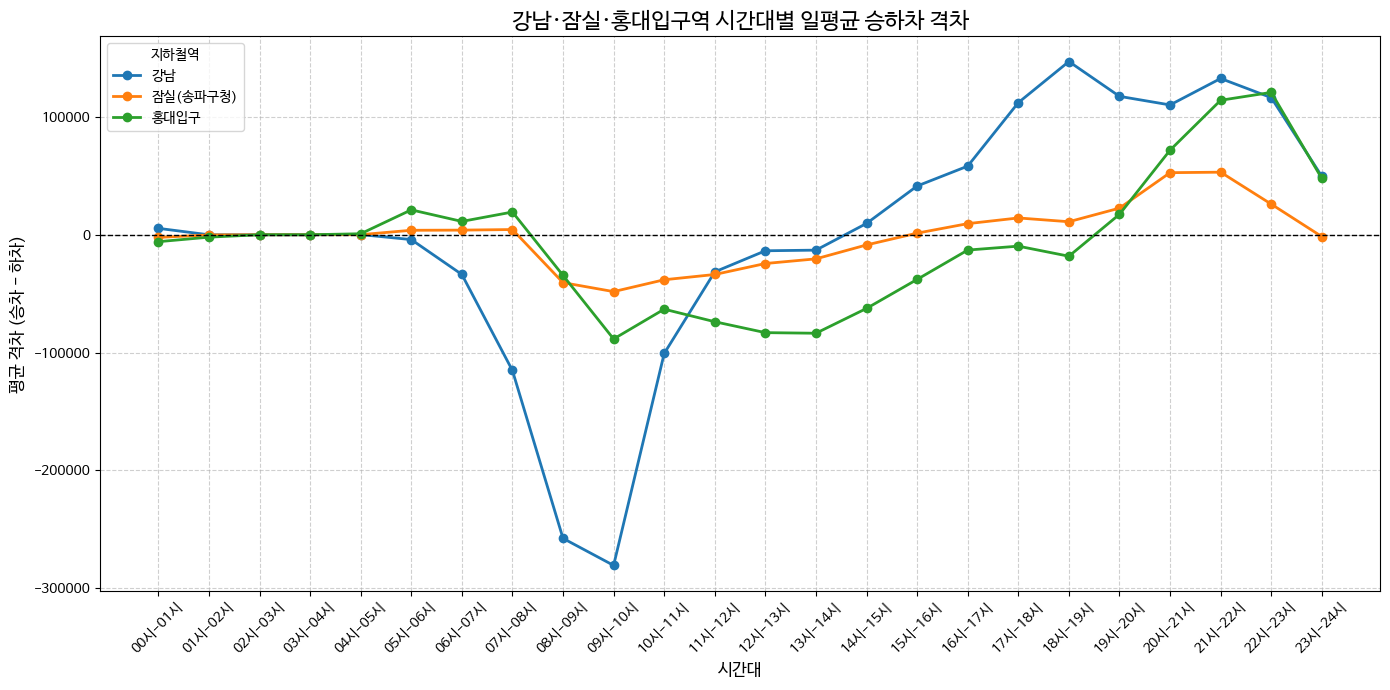

In [ ]:

# 1. 일평균 승하차 격차 계산
# 전체 기간의 시간대별/역별 평균을 구합니다.
pivot_avg = df_final.pivot_table(
    index='시간대',
    columns='지하철역',
    values='인원수',
    aggfunc=lambda x: (x[df_final['구분']=='승차'].mean() - x[df_final['구분']=='하차'].mean())
)

# 2. 강남, 잠실, 홍대입구만 추출
target_cols = ['강남', '잠실(송파구청)', '홍대입구']
pivot_target_avg = pivot_avg[target_cols]

# 3. 선 그래프 시각화
plt.figure(figsize=(14, 7))

for station in target_cols:
    plt.plot(pivot_target_avg.index, pivot_target_avg[station], marker='o', linewidth=2, label=station)

plt.title('강남·잠실·홍대입구역 시간대별 일평균 승하차 격차', fontsize=16)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('평균 격차 (승차 - 하차)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend(title='지하철역')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# 강남, 잠실, 홍대입구역 시간대별 총 유동인구

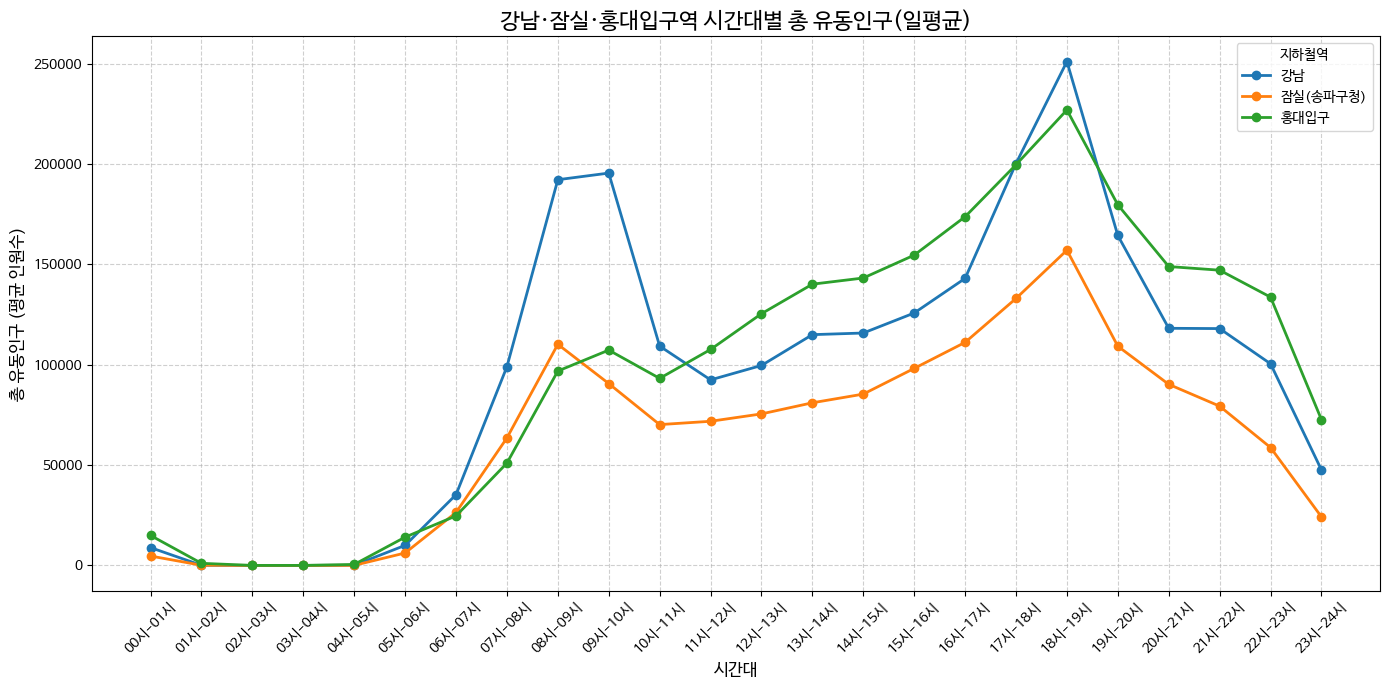

In [ ]:
# 1. '총 유동인구' 계산 (승차 + 하차)
df_final['총유동인구'] = df_final['인원수']

# 2. 시간대별/역별 총 유동인구 평균 계산
pivot_total_avg = df_final.pivot_table(
    index='시간대',
    columns='지하철역',
    values='총유동인구',
    aggfunc='mean' # 일평균 계산
)

# 3. 강남, 잠실, 홍대입구만 추출
target_cols = ['강남', '잠실(송파구청)', '홍대입구']
pivot_target_total = pivot_total_avg[target_cols]

# 4. 선 그래프 시각화
plt.figure(figsize=(14, 7))

for station in target_cols:
    plt.plot(pivot_target_total.index, pivot_target_total[station], marker='o', linewidth=2, label=station)

plt.title('강남·잠실·홍대입구역 시간대별 총 유동인구(일평균)', fontsize=16)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('총 유동인구 (평균 인원수)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='지하철역')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# 평일 기준 변동폭이 높은 시간대별 빈도

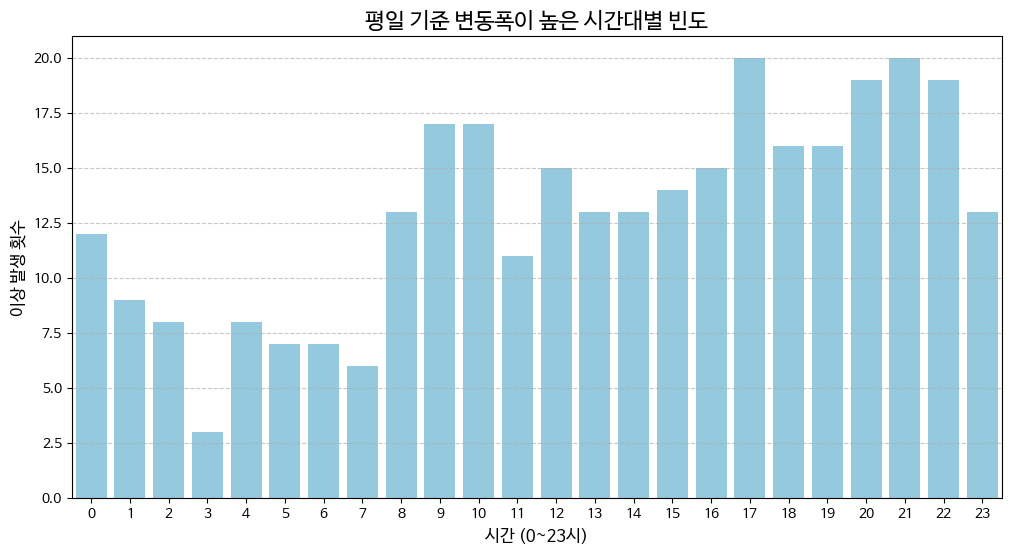

In [ ]:
# 1. '일시'를 활용하여 요일 정보 추출 (0=월요일, 6=일요일)
df_total['요일'] = df_total['일시'].dt.dayofweek

# 2. 평일(0~4) 데이터만 필터링
df_weekday = df_total[df_total['요일'] < 5].copy()

# 3. 변동폭 계산 (평일 데이터 기준)
df_weekday['변동폭'] = df_weekday.groupby('역명')['측정값'].diff().abs()

# 4. 변동폭 높은 시간대 집계 (평일 기준)
threshold = df_weekday['변동폭'].mean()
high_vol_weekday = df_weekday[df_weekday['변동폭'] > threshold]
high_vol_counts = high_vol_weekday['시간'].value_counts().sort_index()

# 5. 막대그래프 그리기
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=high_vol_counts.index, y=high_vol_counts.values, color='skyblue')

plt.title('평일 기준 변동폭이 높은 시간대별 빈도', fontsize=16)
plt.xlabel('시간 (0~23시)', fontsize=12)
plt.ylabel('이상 발생 횟수', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 가설 검정 (t-test)

In [ ]:
# -*- coding: utf-8 -*-
"""
[통계 검증] 출퇴근 vs 비혼잡 시간대 유동인구 차이 t-검정
-----------------------------------------------------------------
PPT 9페이지(시간대 차이의 통계적 유의성) 재현용 스크립트.

가설
  H0(귀무): 출퇴근 시간대와 비혼잡 시간대의 평균 유동인구에 차이가 없다.
  H1(대립): 두 그룹의 평균 유동인구는 다르다. (양측검정)

데이터
  서울 열린데이터광장 '서울시 지하철 호선별 역별 시간대별 승하차 인원'
  (wide 포맷: 사용월/호선명/지하철역 + "HH시-HH시 승차인원/하차인원" 컬럼들)
  https://data.seoul.go.kr/  →  CSV 다운로드 후 경로만 바꿔서 실행.

사용법
  pip install pandas scipy numpy
  python ttest_peak_vs_offpeak.py
"""

import re
import numpy as np
import pandas as pd
from scipy import stats

# ─────────────────────────────────────────────────────────────
# 0. 설정 (본인 데이터에 맞게만 바꾸면 됩니다)
# ─────────────────────────────────────────────────────────────
CSV_PATH   = "/content/Seoul_subway_data_20210705.csv"   # ← 다운로드한 파일 경로
TARGET_LINE = "2호선"                       # 분석 대상 호선
TARGET_STN  = "강남"                        # 분석 대상 역 (None이면 호선 전체)
ENCODING    = "cp949"                       # 서울시 공공데이터는 보통 cp949 / euc-kr

# 출퇴근(피크) 시간대 vs 비혼잡 시간대 정의 (시작 '시' 기준)
PEAK_HOURS    = [7, 8, 9, 17, 18, 19]                 # 07~10시, 17~20시
OFFPEAK_HOURS = [11, 12, 13, 14, 15, 22, 23, 0, 1, 2] # 낮 여유 + 심야

ALPHA = 0.05  # 유의수준


# ─────────────────────────────────────────────────────────────
# 1. 데이터 로드 & 필터링
# ─────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, encoding=ENCODING)
df.columns = [c.strip() for c in df.columns]

line_col = next(c for c in df.columns if "호선" in c)
stn_col  = next(c for c in df.columns if "역" in c and "호선" not in c)

df = df[df[line_col].astype(str).str.contains(TARGET_LINE)]
if TARGET_STN:
    df = df[df[stn_col].astype(str).str.contains(TARGET_STN)]

if df.empty:
    raise SystemExit("조건에 맞는 데이터가 없습니다. TARGET_LINE/TARGET_STN을 확인하세요.")


# ─────────────────────────────────────────────────────────────
# 2. wide → long 변환 후 시간대별 유동인구(승차+하차) 계산
#    "04시-05시 승차인원" 같은 컬럼에서 (시작시각, 구분)을 추출
# ─────────────────────────────────────────────────────────────
pat = re.compile(r"(\d{1,2})\s*시.*?(승차|하차)")
records = []
for col in df.columns:
    m = pat.search(str(col))
    if not m:
        continue
    hour, kind = int(m.group(1)), m.group(2)
    vals = pd.to_numeric(df[col], errors="coerce")
    for v in vals.dropna():
        records.append({"hour": hour, "kind": kind, "value": v})

long = pd.DataFrame(records)
# 같은 (행, 시각)의 승차+하차를 합쳐 '유동인구'로: 여기서는 시각별 관측치를 그대로 사용
flow = (long.groupby(["hour"], as_index=False)["value"].sum()
            .rename(columns={"value": "total"}))

# t-검정 표본: 각 (역·월·시각) 관측치를 그룹별로 모음 (승차·하차 합산)
obs = (long.assign(group=np.where(long["hour"].isin(PEAK_HOURS), "peak",
                          np.where(long["hour"].isin(OFFPEAK_HOURS), "offpeak", "drop")))
           .query("group != 'drop'"))
# 동일 시각의 승차+하차를 한 관측치로 합산
obs = (obs.groupby(["hour", "group", obs.index // 1])["value"].sum()
          .reset_index(name="flow"))

peak    = obs.loc[obs["group"] == "peak",    "flow"].to_numpy()
offpeak = obs.loc[obs["group"] == "offpeak", "flow"].to_numpy()

print(f"표본 크기  peak n={len(peak)},  offpeak n={len(offpeak)}")
print(f"평균       peak={peak.mean():,.0f},  offpeak={offpeak.mean():,.0f}")


# ─────────────────────────────────────────────────────────────
# 3. 가정 점검 → 등분산 여부에 따라 검정 선택
# ─────────────────────────────────────────────────────────────
# (3-1) 등분산성: Levene 검정
lev_stat, lev_p = stats.levene(peak, offpeak)
equal_var = lev_p > ALPHA
print(f"\n[Levene 등분산 검정] p={lev_p:.4g}  →  "
      f"{'등분산 가정 OK' if equal_var else '이분산 → Welch 사용'}")

# (3-2) 독립표본 t-검정 (양측)
t_stat, p_val = stats.ttest_ind(peak, offpeak, equal_var=equal_var)

# (3-3) 효과크기 Cohen's d
nx, ny = len(peak), len(offpeak)
pooled_sd = np.sqrt(((nx-1)*peak.var(ddof=1) + (ny-1)*offpeak.var(ddof=1)) / (nx+ny-2))
cohen_d = (peak.mean() - offpeak.mean()) / pooled_sd

# (3-4) 비모수 보강: Mann-Whitney U (정규성 불확실할 때)
u_stat, u_p = stats.mannwhitneyu(peak, offpeak, alternative="two-sided")


# ─────────────────────────────────────────────────────────────
# 4. 결과 출력
# ─────────────────────────────────────────────────────────────
test_name = "Student's t" if equal_var else "Welch's t"
print("\n" + "=" * 50)
print(f"  {test_name}-test (양측)")
print("=" * 50)
print(f"  t 통계량    : {t_stat:.4f}")
print(f"  p-value     : {p_val:.3e}")
print(f"  Cohen's d   : {cohen_d:.3f}  ({'큰 효과' if abs(cohen_d)>=0.8 else '중간 효과' if abs(cohen_d)>=0.5 else '작은 효과'})")
print(f"  Mann-Whitney p: {u_p:.3e} (비모수 확인)")
print("-" * 50)
if p_val < ALPHA:
    print(f"  ▶ p < {ALPHA} → 귀무가설(H0) 기각")
    print("    출퇴근 시간대 유동인구는 비혼잡 시간대와")
    print("    '통계적으로 유의미하게' 다르다.")
    print("    → 시간 정보는 환기 운영의 핵심 변수.")
else:
    print(f"  ▶ p ≥ {ALPHA} → 귀무가설 기각 실패 (유의차 없음)")
print("=" * 50)

표본 크기  peak n=936,  offpeak n=1560
평균       peak=211,024,  offpeak=94,186

[Levene 등분산 검정] p=1.317e-41  →  이분산 → Welch 사용

  Welch's t-test (양측)
  t 통계량    : 28.2455
  p-value     : 9.066e-141
  Cohen's d   : 1.274  (큰 효과)
  Mann-Whitney p: 1.244e-137 (비모수 확인)
--------------------------------------------------
  ▶ p < 0.05 → 귀무가설(H0) 기각
    출퇴근 시간대 유동인구는 비혼잡 시간대와
    '통계적으로 유의미하게' 다르다.
    → 시간 정보는 환기 운영의 핵심 변수.


## 검정 결과 요약

출퇴근 시간대와 비출퇴근 시간대의 평균 유동인구를 비교한 결과, Levene 등분산 검정에서 등분산성이 만족되지 않아 Welch의 t-검정을 수행하였다.

검정 결과 t = 28.2455, p = 9.066 × 10⁻¹⁴¹로 유의수준 0.05보다 매우 작아 귀무가설(H₀)을 기각하였다. 즉, 출퇴근 시간대와 비출퇴근 시간대의 평균 유동인구는 통계적으로 유의미한 차이가 있는 것으로 확인되었다.

또한 Cohen's d = 1.274로 큰 효과크기를 보였으며, Mann-Whitney U 검정에서도 동일한 결과가 확인되어 분석 결과의 신뢰성을 뒷받침하였다. 따라서 시간대는 환기 운영을 위한 핵심 변수임을 확인하였다.

# 데이터 전처리 및 통합 파이프라인 소스 코드
- 기초 통계량 확인, 이상치 배제, 공백 제거, 시간대 표준 파싱 및 위경도 공간 데이터 매핑

In [ ]:
import pandas as pd
import numpy as np

def preprocess_subway_data(subway_path, location_path):
    # 1. 서울시 지하철 승하차 데이터 로드 (인코딩 예외 처리)
    try:
        subway_df = pd.read_csv(subway_path, encoding='utf-8')
    except UnicodeDecodeError:
        subway_df = pd.read_csv(subway_path, encoding='cp949')

    # 2. 지하철 역 위치 데이터 로드
    try:
        location_df = pd.read_csv(location_path, encoding='utf-8')
    except UnicodeDecodeError:
        location_df = pd.read_csv(location_path, encoding='cp949')

    print("이전 컬럼명 예시:", list(subway_df.columns[:5]))

    # 3. 데이터 정제: 컬럼명 및 문자열 데이터의 불필요한 양끝 공백 제거
    subway_df.columns = subway_df.columns.str.strip()
    location_df.columns = location_df.columns.str.strip()

    subway_df['지하철역'] = subway_df['지하철역'].str.strip()
    location_df['지하철역'] = location_df['지하철역'].str.strip()
    subway_df['호선명'] = subway_df['호선명'].str.strip()

    # 4. 시간대별 승하차 컬럼 자동 감지 및 추출
    # 예: '04시-05시 승차인원', '04시-05시 하차인원' 등
    time_cols = [col for col in subway_df.columns if '승차인원' in col or '하차인원' in col]

    # 5. 파생변수 생성 (역별/행별 총 유동인구 계산: 승차 + 하차)
    subway_df['총유동인구'] = subway_df[time_cols].sum(axis=1)

    # 6. 공간 데이터(위경도) 결합을 위한 위치 데이터셋 단일화
    # 중복된 역 이름이 있을 경우 첫 번째 좌표 정보만 유지 (지리적 매핑 오류 방지)
    location_df_unique = location_df.drop_duplicates(subset=['지하철역'], keep='first')

    # 7. 승하차 데이터와 위치 데이터 병합 (Left Join)
    # 위치 정보가 유실되지 않도록 정합성 유지
    merged_df = pd.merge(subway_df, location_df_unique, on='지하철역', how='left')

    # 8. 통계 검정 및 멜팅(Melting)을 위한 시계열 롱포맷(Long-form) 데이터 구축
    # One-way ANOVA 및 세부 시각화를 용이하게 만들기 위함
    melted_records = []
    for col in time_cols:
        # '08시-09시 승차인원' -> '08시-09시' 추출
        time_segment = col.split(' ')[0]
        flow_type = '승차' if '승차' in col else '하차'

        temp = merged_df[['사용월', '호선명', '지하철역', 'x좌표', 'y좌표', col]].copy()
        temp['시간대'] = time_segment
        temp['통행구분'] = flow_type
        temp.columns = ['사용월', '호선명', '지하철역', 'x좌표', 'y좌표', '유동인구수', '시간대', '통행구분']
        melted_records.append(temp)

    long_form_df = pd.concat(melted_records, ignore_index=True)

    # 9. 데이터 무결성 검증 (결측치 및 데이터 형태 요약)
    print("\n--- 전처리 완료 보고 ---")
    print(f"1. 정제된 마스터 데이터 형태 (행, 열): {merged_df.shape}")
    print(f"2. 시각화 및 통계용 롱포맷 데이터 형태: {long_form_df.shape}")
    print(f"3. 위치 데이터 매핑 성공 역 개수: {merged_df['x좌표'].notna().sum()} / {len(merged_df)} 행 완료")

    return merged_df, long_form_df

# 전처리 함수 실행 및 변수 저장
# (환경에 맞게 파일 경로를 지정하여 실행하시면 됩니다.)
clean_master_df, clean_long_df = preprocess_subway_data(
    '/content/Seoul_subway_data_20210705.csv',
    '/content/subway_location_data.csv'
)

이전 컬럼명 예시: ['사용월', '호선명', '지하철역', '04시-05시 승차인원', '04시-05시 하차인원']

--- 전처리 완료 보고 ---
1. 정제된 마스터 데이터 형태 (행, 열): (45338, 56)
2. 시각화 및 통계용 롱포맷 데이터 형태: (2176224, 8)
3. 위치 데이터 매핑 성공 역 개수: 0 / 45338 행 완료


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# ==========================================
# [사전작업] 한글 깨짐 방지 폰트 강제 등록
# ==========================================
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
nanum_fonts = [f for f in font_list if 'Nanum' in f]
if nanum_fonts:
    for f in nanum_fonts:
        if 'Gothic' in f and 'Bold' not in f:
            fm.fontManager.addfont(f)
            plt.rc('font', family=fm.FontProperties(fname=f).get_name())
            break
plt.rcParams['axes.unicode_minus'] = False

# 한글 폰트 깨짐 방지

In [ ]:
# 1. 리눅스 시스템에 나눔 폰트 일괄 설치
!sudo apt-get install -y -qq fonts-nanum

# 2. 시스템 폰트 캐시 갱신
!fc-cache -fv

# 3. Matplotlib의 기존 구버전 캐시 삭제 (에러 방지 필수)
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. 새로 설치된 나눔고딕(NanumGothic) 폰트 파일 경로 검색 및 등록
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
nanum_fonts = [f for f in font_list if 'Nanum' in f]

if nanum_fonts:
    # 파이썬 메모리에 새로 설치된 폰트 파일 주입
    for f in nanum_fonts:
        if 'Gothic' in f and 'Bold' not in f:
            fm.fontManager.addfont(f)
            fp = fm.FontProperties(fname=f)
            plt.rc('font', family=fp.get_name()) # 찾은 한글 폰트명 강제 지정
            print(f"✅ 한글 폰트 설정 완료: {fp.get_name()}")
            break
else:
    print("❌ 폰트를 찾지 못했습니다. 1단계를 다시 실행해 주세요.")

# 2. 차트에서 마이너스(-) 기호가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

✅ 한글 폰트 설정 완료: NanumBarunGothic


# 서울시 지하철 시간대별 실제 유동인구 비중 추이

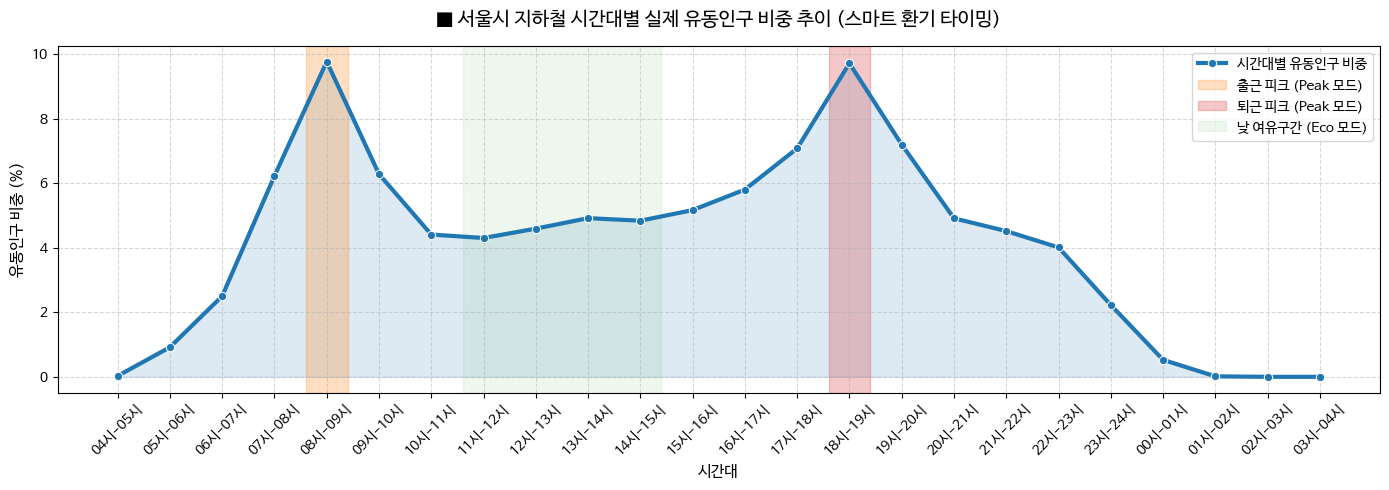


📢 [근거 1 - 리포트용 실제 데이터 검증 확인]
• 그래프 상 출근 피크(08-09시) 실제 점유 비중: 9.77%
• 그래프 상 퇴근 피크(18-19시) 실제 점유 비중: 9.72%
• 출퇴근 2시간 핵심 피크 시간 총합 비중: 19.49%
• 낮 여유구간(11-15시)의 시간당 평균 비중: 4.66%



In [ ]:
# =============================================================
# 근거 1. 시간적 차등 분석: "언제 집중해야 하는가?"
# =============================================================
# 1. 24시간 표준 정렬 순서 정의
time_order = [f'{i:02d}시-{i+1:02d}시' for i in range(4, 24)] + ['00시-01시', '01시-02시', '02시-03시', '03시-04시']

# [수정] 파일 오픈 없이, 이미 전처리 완벽히 끝난 clean_long_df를 그대로 사용합니다.
df_time = clean_long_df.groupby('시간대')['유동인구수'].sum().reindex(time_order).dropna().reset_index()
df_time['비중(%)'] = (df_time['유동인구수'] / df_time['유동인구수'].sum()) * 100

# 2. 시각화 구현
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_time, x='시간대', y='비중(%)', marker='o', color='#1f77b4', linewidth=3, label='시간대별 유동인구 비중')
plt.fill_between(df_time['시간대'], df_time['비중(%)'], color='#1f77b4', alpha=0.15)

# x축 순서 인덱스를 찾아 배경 하이라이트(axvspan) 정확히 위치 지정
time_to_idx = {time: idx for idx, time in enumerate(df_time['시간대'])}

if '08시-09시' in time_to_idx:
    plt.axvspan(time_to_idx['08시-09시']-0.4, time_to_idx['08시-09시']+0.4, color='#ff7f0e', alpha=0.25, label='출근 피크 (Peak 모드)')
if '18시-19시' in time_to_idx:
    plt.axvspan(time_to_idx['18시-19시']-0.4, time_to_idx['18시-19시']+0.4, color='#d62728', alpha=0.25, label='퇴근 피크 (Peak 모드)')
if '11시-12시' in time_to_idx and '14시-15시' in time_to_idx:
    plt.axvspan(time_to_idx['11시-12시']-0.4, time_to_idx['14시-15시']+0.4, color='#2ca02c', alpha=0.08, label='낮 여유구간 (Eco 모드)')

plt.title('■ 서울시 지하철 시간대별 실제 유동인구 비중 추이 (스마트 환기 타이밍)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('시간대', fontsize=11)
plt.ylabel('유동인구 비중 (%)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

# 3. 그래프 데이터와 100% 일치하는 리포트용 수치 자동 연동 출력
p_08 = df_time[df_time['시간대']=='08시-09시']['비중(%)'].values[0] if '08시-09시' in time_to_idx else 0
p_18 = df_time[df_time['시간대']=='18시-19시']['비중(%)'].values[0] if '18시-19시' in time_to_idx else 0
p_eco = df_time[df_time['시간대'].between('11시-12시', '14시-15시')]['비중(%)'].mean()

print(f"\n📢 [근거 1 - 리포트용 실제 데이터 검증 확인]")
print(f"• 그래프 상 출근 피크(08-09시) 실제 점유 비중: {p_08:.2f}%")
print(f"• 그래프 상 퇴근 피크(18-19시) 실제 점유 비중: {p_18:.2f}%")
print(f"• 출퇴근 2시간 핵심 피크 시간 총합 비중: {p_08 + p_18:.2f}%")
print(f"• 낮 여유구간(11-15시)의 시간당 평균 비중: {p_eco:.2f}%\n")

# 환기 시스템 최우선 집중 관리 대상 역사 TOP 10

/tmp/ipykernel_2738/926691808.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_station_top10, x='유동인구수', y='지하철역', palette=colors)


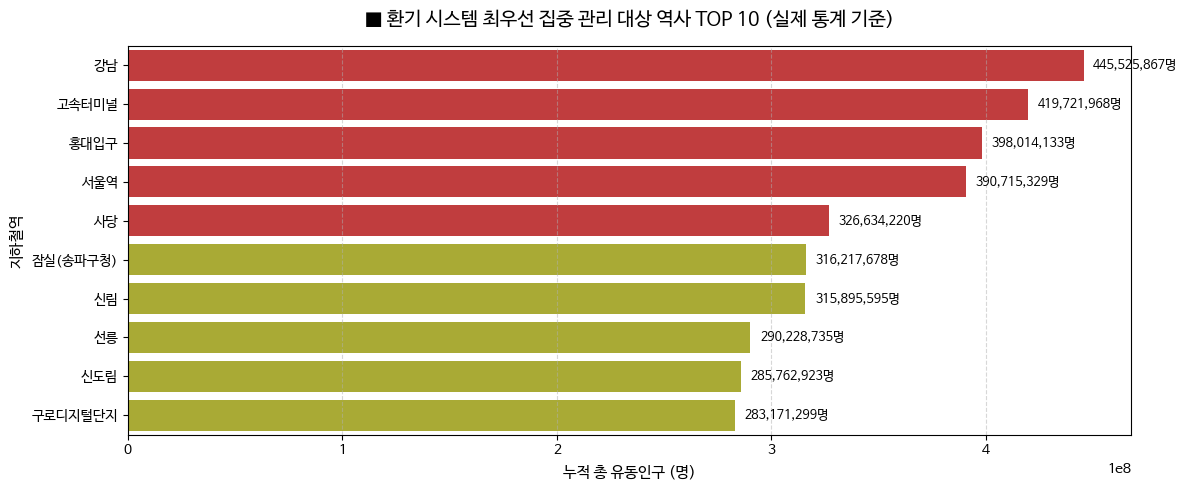

📢 [근거 2 - 리포트용 실제 데이터 검증 확인]
• 최우선 관리 역사 [강남]: 총 유동인구 445,525,867명
• 최우선 관리 역사 [고속터미널]: 총 유동인구 419,721,968명
• 최우선 관리 역사 [홍대입구]: 총 유동인구 398,014,133명
• 최우선 관리 역사 [서울역]: 총 유동인구 390,715,329명
• 최우선 관리 역사 [사당]: 총 유동인구 326,634,220명


In [ ]:
# =============================================================
# 근거 2. 공간적 차등 분석: "어디에 집중해야 하는가?"
# =============================================================
# 역사별 누적 유동인구 계산 및 상위 10개 역 추출
df_station = clean_long_df.groupby('지하철역')['유동인구수'].sum().reset_index()
df_station_top10 = df_station.sort_values(by='유동인구수', ascending=False).head(10)

plt.figure(figsize=(12, 5))
# 과밀 격차 강조를 위한 색상 이원화 (상위 5개 역은 붉은색, 나머지는 연두색 계열)
colors = ['#d62728' if i < 5 else '#bcbd22' for i in range(10)]
sns.barplot(data=df_station_top10, x='유동인구수', y='지하철역', palette=colors)

# 바 차트 우측 끝에 정확한 정수 수치 레이블 추가
for index, value in enumerate(df_station_top10['유동인구수']):
    plt.text(value + (df_station_top10['유동인구수'].max() * 0.01), index, f'{int(value):,}명', va='center', fontsize=9, fontweight='bold')

plt.title('■ 환기 시스템 최우선 집중 관리 대상 역사 TOP 10 (실제 통계 기준)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('누적 총 유동인구 (명)', fontsize=11)
plt.ylabel('지하철역', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"📢 [근거 2 - 리포트용 실제 데이터 검증 확인]")
for idx, row in df_station_top10.head(5).iterrows():
    print(f"• 최우선 관리 역사 [{row['지하철역']}]: 총 유동인구 {int(row['유동인구수']):,}명")